# <p style="text-align: center; color: #875DAF;">Proiect 5 Ensemble - </p>
### <p style="text-align: right; color:  #875DAF;">Iliescu Daria-Gabriela, 1333a</p>

In [76]:
# Importarea bibliotecilor
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Explorarea inițială a datelor 

In [77]:
# Citirea fișierul CSV
df = pd.read_csv('ensemble_1.csv')

In [78]:
# Verificarea primelor 5 rânduri pentru a confirma încărcarea corectă
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [79]:
# Eliminarea coloanelor irelevante

df = df.drop(['ID', 'ZIP Code'], axis=1)

In [80]:
# Afișarea primelor 5 observații

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [81]:
df.shape

(5000, 12)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal Loan       5000 non-null   int64  
 8   Securities Account  5000 non-null   int64  
 9   CD Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


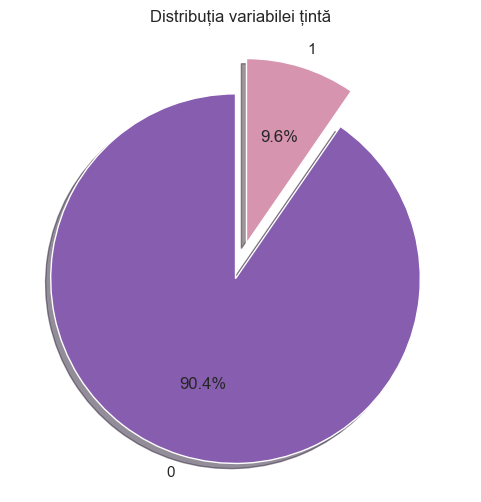

In [83]:
counts = df['Personal Loan'].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    explode=[0.1, 0.1],  # corectat
    colors=[ '#875DAF', '#D794AF'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title('Distribuția variabilei țintă')
plt.show()

**<span style="color:  #875DAF">In analiza persoanelor care au acceptat sau nu au acceptat un imprumut personal, se constata ca in setul de date predomina cei ce nu au acceptat (90.4%) , fata de cei care au acceptat (9.6%).</span>**


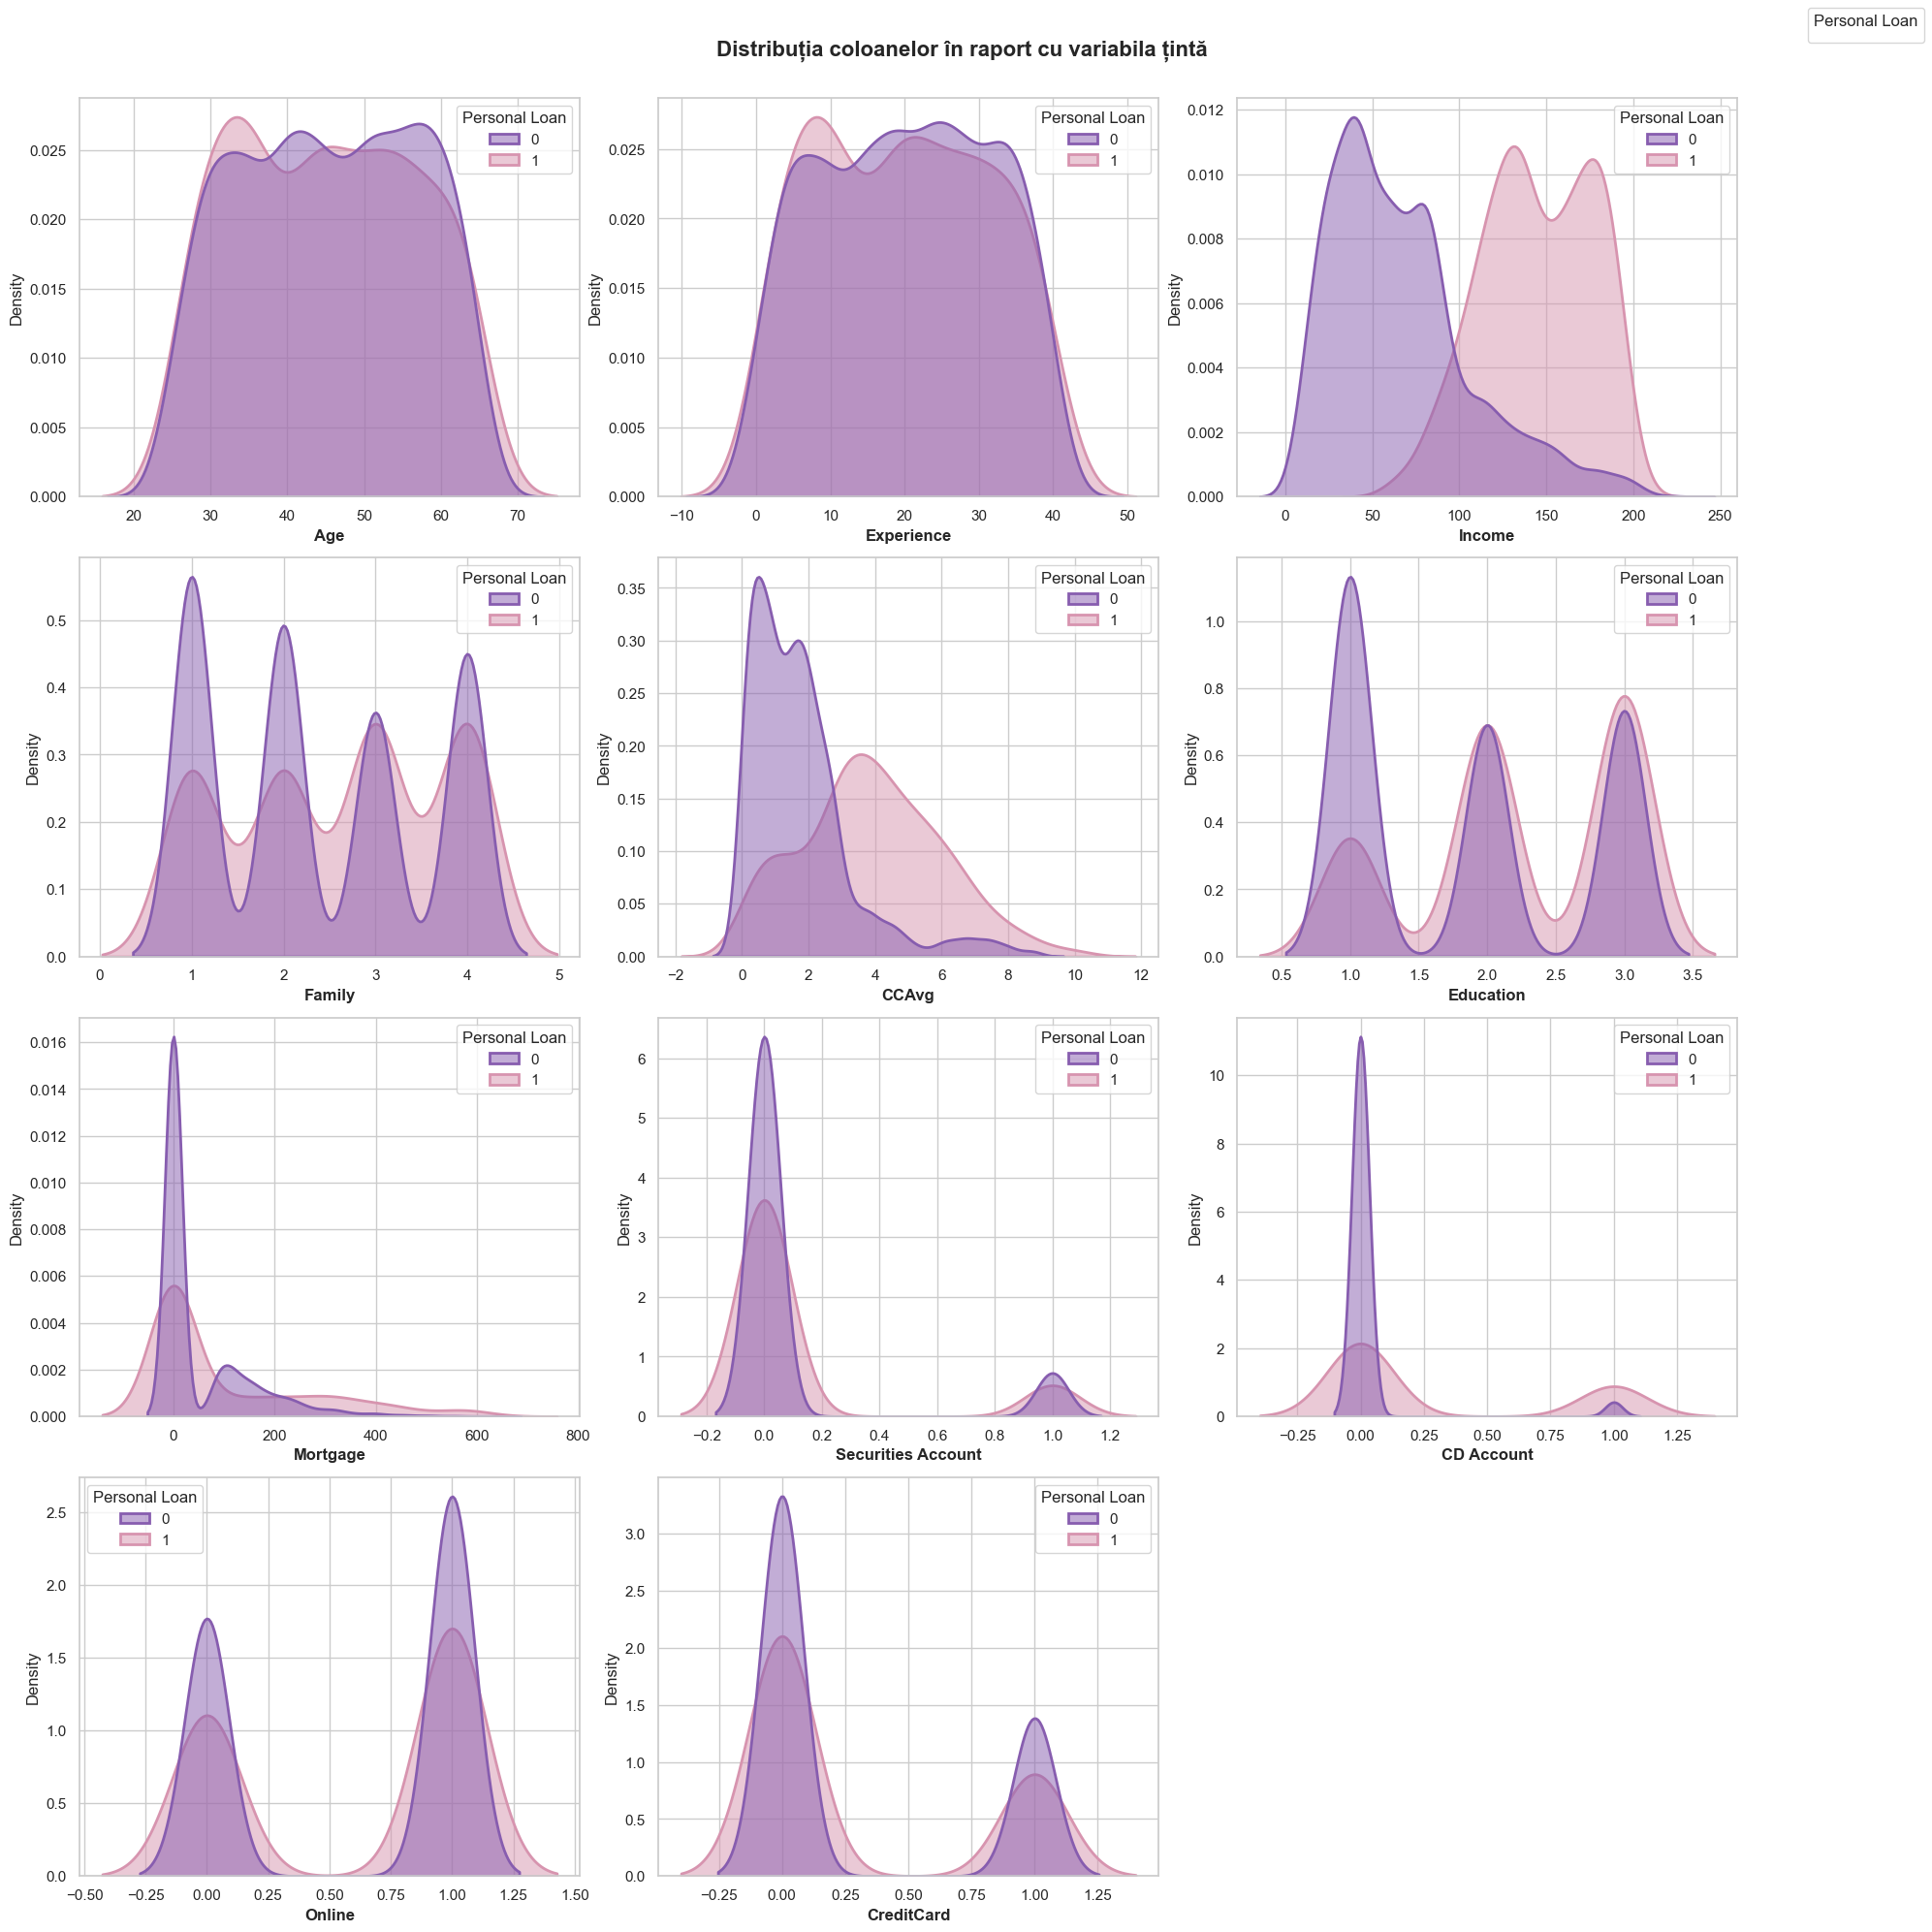

In [84]:
sns.set(style="whitegrid")

columns = df.drop('Personal Loan', axis=1).columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.kdeplot(
        x=col, 
        data=df, 
        hue='Personal Loan', 
        fill=True,
        palette=['#875DAF', '#D794AF'], 
        alpha=0.5, 
        lw=2, 
        ax=axes[i],
        common_norm=False
    )
    axes[i].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=12)
    
# Setăm legenda doar o singură dată, folosind handles și labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Personal Loan', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuția coloanelor în raport cu variabila țintă', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()

- Din grafice se vede ca unele variabile au distributii diferite intre persoanele care au luat imprumutul si cele care nu au luat. De exemplu, cei care au acceptat imprumutul au venituri mai mari (Income), cheltuiesc mai mult pe card (CCAvg) si au mai des un cont CD. Aceste diferente arata ca aceste variabile sunt legate de decizia de a lua imprumutul. In schimb, variabile precum varsta, experienta sau marimea familiei arata distributii asemanatoare pentru ambele grupuri, ceea ce sugereaza ca nu influenteaza prea mult decizia finala.
- Dimensiunea la aceasta etapa este de 12 coloane si 5000 linii.

### 2. Analiza datelor și curățarea  

In [85]:
df.isnull().sum()

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(13)

In [87]:
# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('Personal Loan', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)

Numărul de outlieri per coloană (sortat descrescător):
Securities Account    522
CCAvg                 324
CD Account            302
Mortgage              291
Income                 96
Age                     0
Experience              0
Family                  0
Education               0
Online                  0
CreditCard              0
dtype: int64


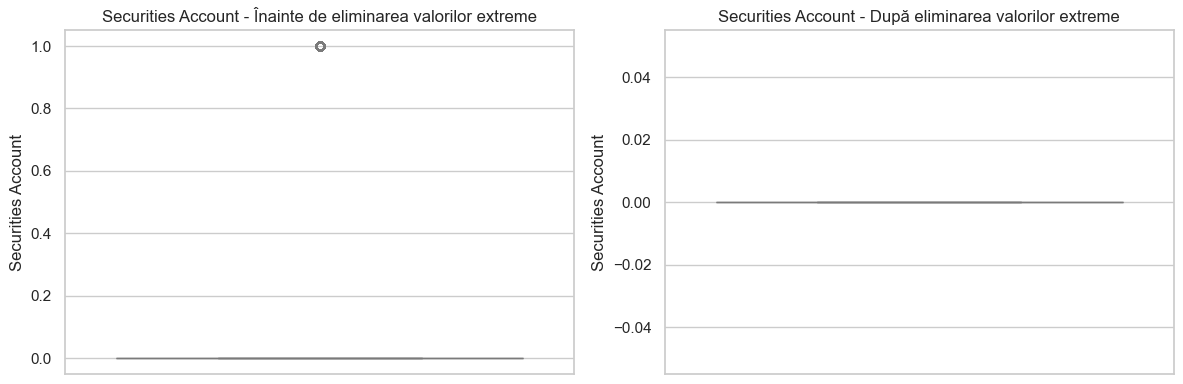

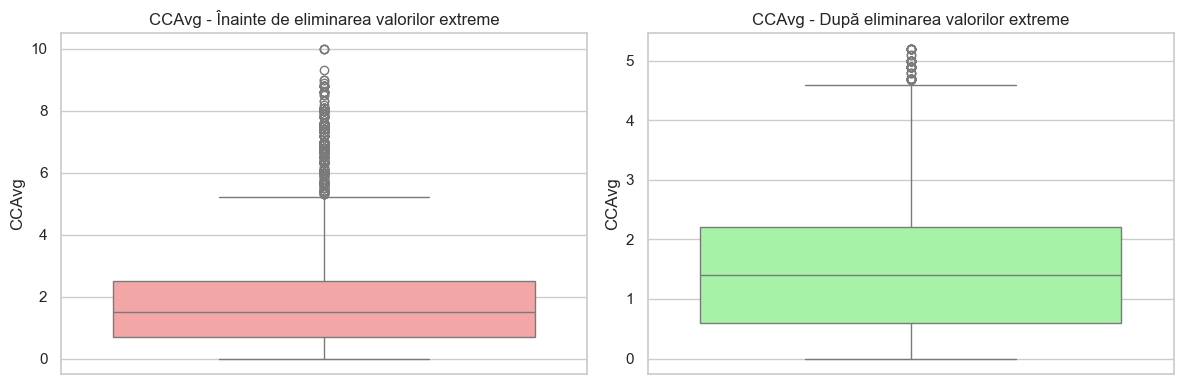

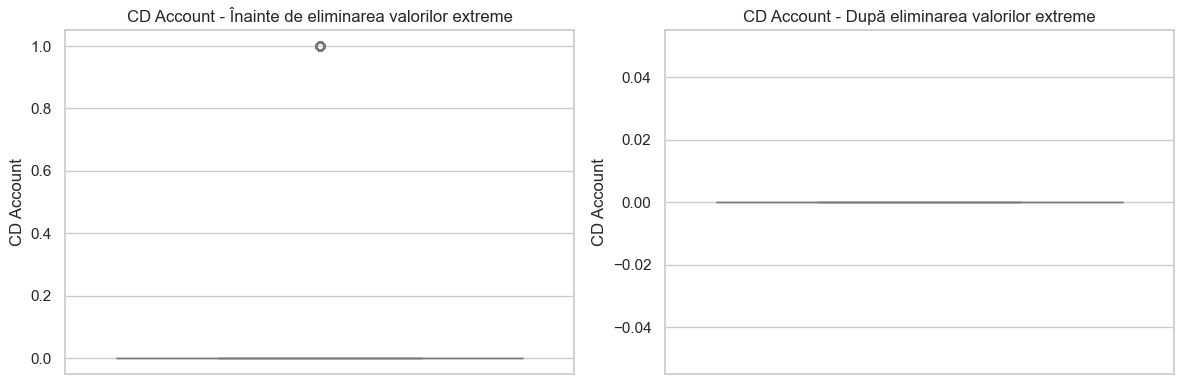

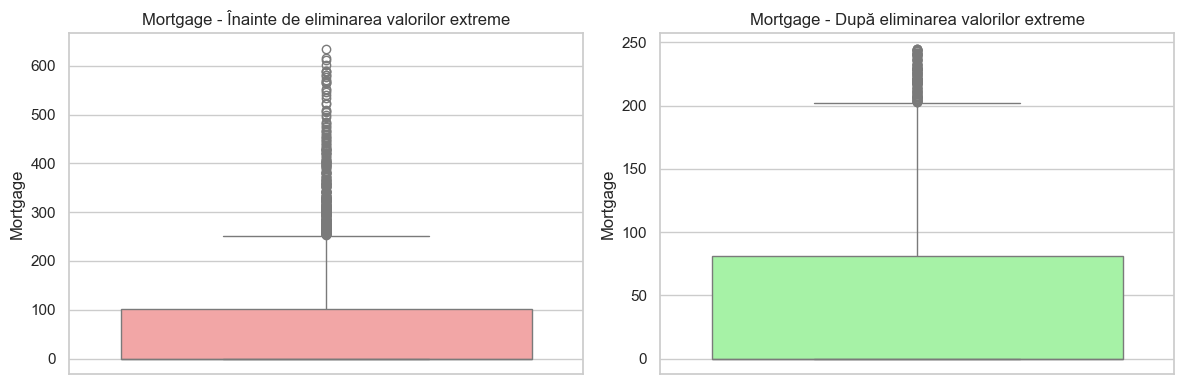

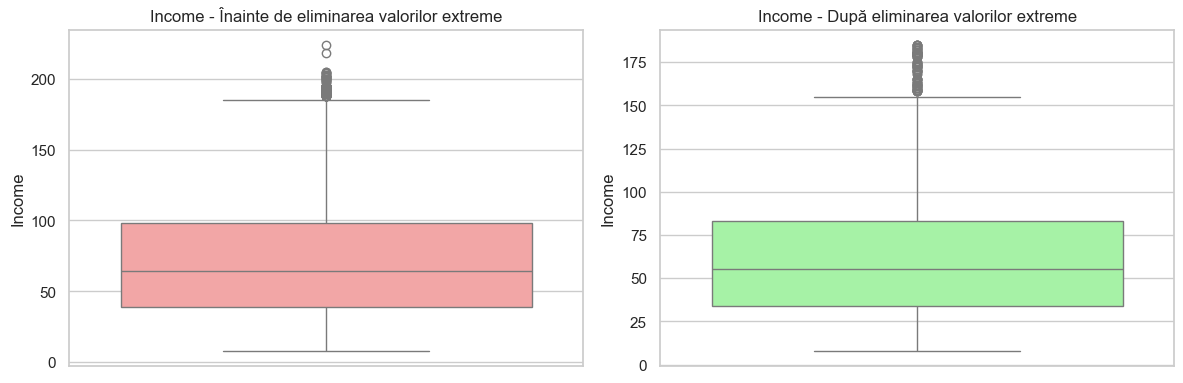

In [88]:

sns.set(style="whitegrid")

# Selectăm primii 5 coloane cu cei mai mulți outlieri
top5_cols = outliers_series.index[:5]

# Copiem dataset-ul pentru comparație
df_before = df.copy()
df_after = df.copy()

# Eliminăm outlierii pentru toate coloanele numerice
for col in df_after.drop('Personal Loan', axis=1).columns:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_after = df_after[(df_after[col] >= lower_bound) & (df_after[col] <= upper_bound)]

# Vizualizare boxplot înainte și după pentru primii 5 outlieri
for col in top5_cols:
    plt.figure(figsize=(12,4))

    # Boxplot înainte
    plt.subplot(1,2,1)
    sns.boxplot(y=df_before[col], color='#FF9999')
    plt.title(f'{col} - Înainte de eliminarea valorilor extreme')

    # Boxplot după eliminare
    plt.subplot(1,2,2)
    sns.boxplot(y=df_after[col], color='#99FF99')
    plt.title(f'{col} - După eliminarea valorilor extreme')

    plt.tight_layout()
    plt.show()


In [89]:
df = df.drop_duplicates()


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df.shape

(4987, 12)


  Observam ca nu avem variabile categoriale (0), iar variabila noastra tinta 'Personal Loan' este deja in formatul numeric specific pentru modelare. Numarul variabilelor numerice este 12. 
  Am verificat datele si nu existau valori lipsa, dar am gasit valori extreme in mai multe variabile numerice. Acesti outlieri au fost eliminati folosind metoda IQR. De asemenea, am sters si valorile duplicate pentru a pastra doar inregistrari unice. Dupa aceste curatari, setul de date a ramas cu 4987 de randuri si 12 coloane.

### 3. Preprocesarea si pregatirea pentru modelare

In [92]:
corr = df.corr()
corr

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994221,-0.056897,-0.045533,-0.052522,0.042356,-0.013014,-0.008003,-0.000715,0.007849,0.013989,0.006381
Experience,0.994221,1.000000,-0.048277,-0.051718,-0.050597,0.014166,-0.011083,-0.007708,-0.001529,0.010151,0.014245,0.007628
Income,-0.056897,-0.048277,1.000000,-0.157922,0.646065,-0.186847,0.206420,0.502513,-0.002992,0.169589,0.014646,-0.003479
Family,-0.045533,-0.051718,-0.157922,1.000000,-0.109801,0.066145,-0.020595,0.061398,0.019957,0.014081,0.009907,0.012018
CCAvg,-0.052522,-0.050597,0.646065,-0.109801,1.000000,-0.135285,0.109162,0.366671,0.014572,0.136241,-0.002718,-0.007407
Education,0.042356,0.014166,-0.186847,0.066145,-0.135285,1.000000,-0.032256,0.137618,-0.010132,0.014475,-0.015633,-0.010307
Mortgage,-0.013014,-0.011083,0.206420,-0.020595,0.109162,-0.032256,1.000000,0.141700,-0.005909,0.088987,-0.005266,-0.007930
Personal Loan,-0.008003,-0.007708,0.502513,0.061398,0.366671,0.137618,0.141700,1.000000,0.021670,0.316210,0.006718,0.002399
Securities Account,-0.000715,-0.001529,-0.002992,0.019957,0.014572,-0.010132,-0.005909,0.021670,1.000000,0.316883,0.013096,-0.015466
CD Account,0.007849,0.010151,0.169589,0.014081,0.136241,0.014475,0.088987,0.316210,0.316883,1.000000,0.176414,0.278559


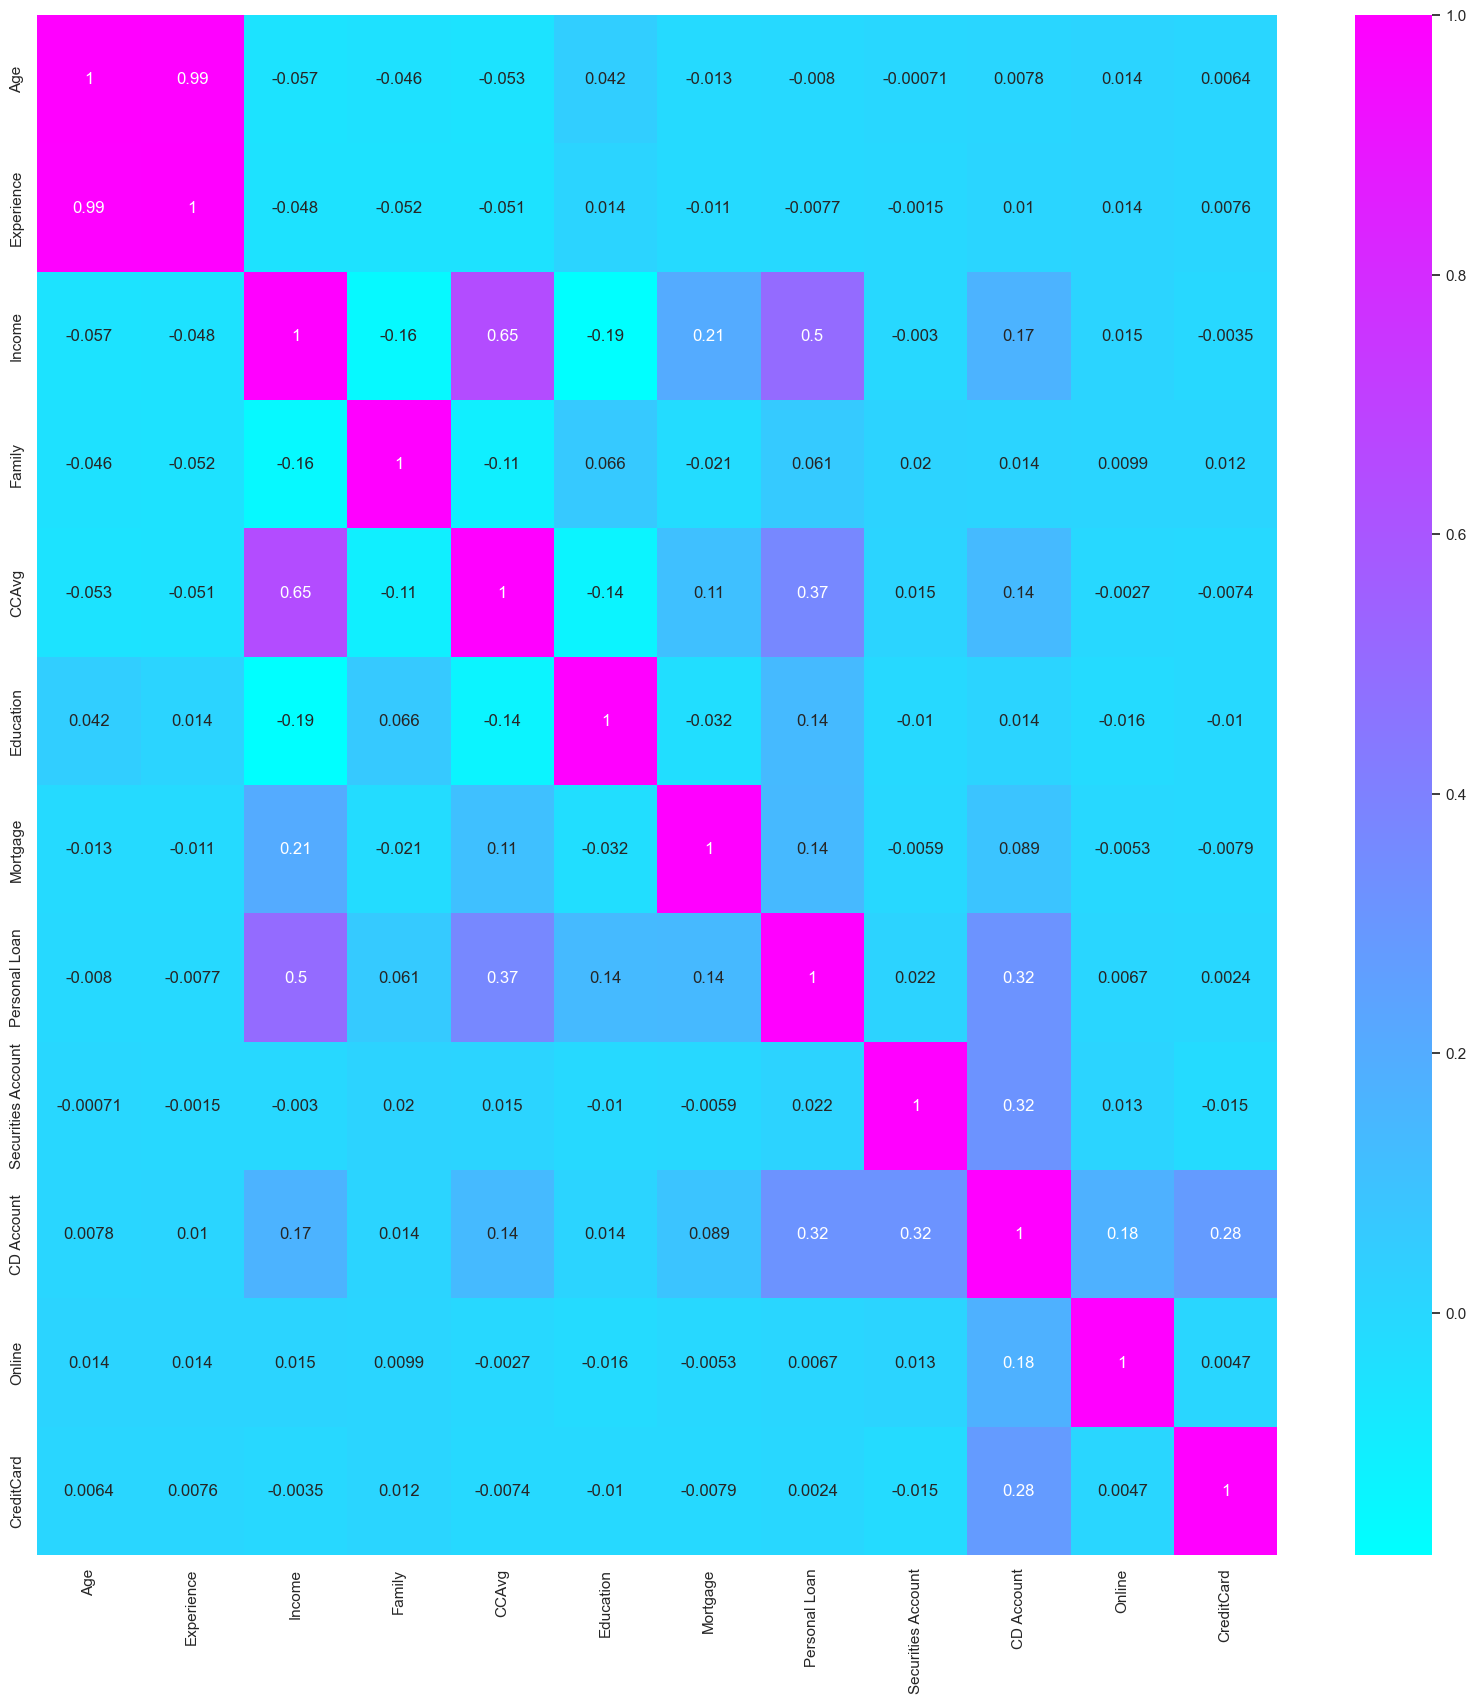

In [93]:

# Calculăm matricea de corelație între toate coloanele numerice
corr = df.corr()

# Setăm dimensiunea figurii
plt.figure(figsize=(20,20))

# Creăm heatmap-ul cu corelațiile
sns.heatmap(corr, cmap='cool', annot=True)

# Afișăm figura
plt.show()


In [94]:
# Matricea de corelație
corr_matrix = df.corr().abs()

# Selectăm doar partea superioară a matricei
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Găsim coloanele care au corelație > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Eliminăm aceste coloane
df_reduced = df.drop(columns=to_drop)

print("Coloane eliminate din cauza multicoliniarității (corelație > 0.8):")
print(to_drop)
print("Formă nouă DataFrame:", df_reduced.shape)

Coloane eliminate din cauza multicoliniarității (corelație > 0.8):
['Experience']
Formă nouă DataFrame: (4987, 11)


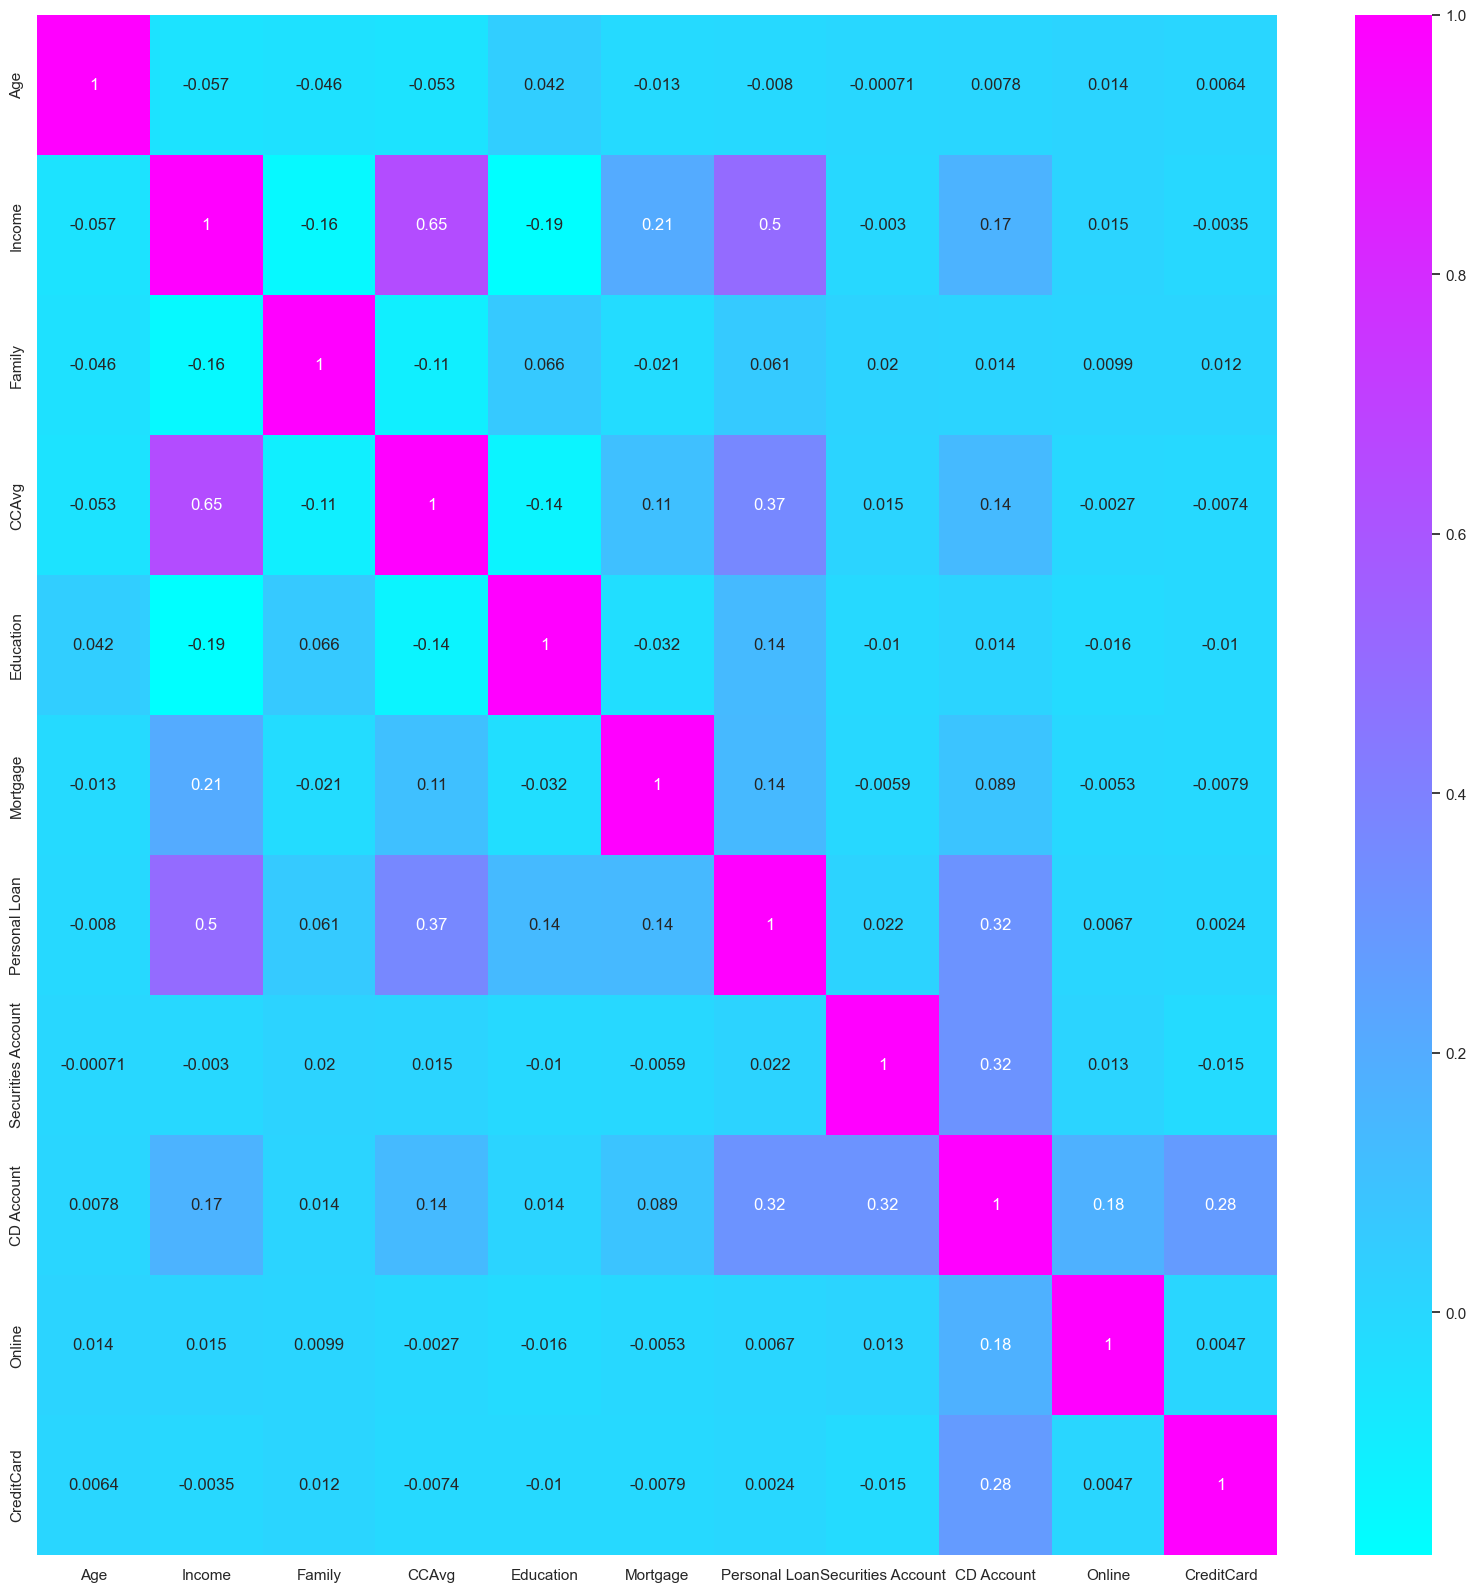

In [95]:
df=df_reduced
# Calculăm matricea de corelație între toate coloanele numerice
corr = df.corr()

# Setăm dimensiunea figurii
plt.figure(figsize=(20,20))

# Creăm heatmap-ul cu corelațiile
# cmap='viridis_r' folosește o schemă de culori inversată
# annot=True afișează valorile numerice pe fiecare pătrat
sns.heatmap(corr, cmap='cool', annot=True)

# Afișăm figura
plt.show()

In [96]:
from sklearn.model_selection import train_test_split

# Separăm variabilele independente (X) de variabila țintă (y)
X = df.drop('Personal Loan', axis=1)  # toate coloanele, mai puțin 'diagnosis'
y = df['Personal Loan']               # variabila țintă

# Împărțim dataset-ul în set de antrenament și set de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verificăm dimensiunile dataset-urilor
print("Dimensiune X_train:", X_train.shape)
print("Dimensiune X_test:", X_test.shape)
print("Dimensiune y_train:", y_train.shape)
print("Dimensiune y_test:", y_test.shape)


Dimensiune X_train: (3490, 10)
Dimensiune X_test: (1497, 10)
Dimensiune y_train: (3490,)
Dimensiune y_test: (1497,)


In [97]:
from sklearn.preprocessing import StandardScaler

# Inițializăm scaler-ul
scaler = StandardScaler()

# Aplicăm scalarea pe setul de antrenament și test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertim în DataFrame păstrând numele coloanelor
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verificăm primele rânduri
print("X_train_scaled_df:")
display(X_train_scaled_df.head())

print("X_test_scaled_df:")
display(X_test_scaled_df.head())

X_train_scaled_df:


,Age,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
1409,-0.367823,-0.249572,-0.345019,0.719263,-1.049069,-0.555654,-0.33914,-0.256855,-1.221097,-0.647515
2503,-0.627909,-1.181037,1.405150,-0.892300,0.139649,0.208810,-0.33914,-0.256855,0.818936,1.544365
802,-0.801300,-0.509516,0.530066,0.028593,-1.049069,1.515174,-0.33914,-0.256855,0.818936,-0.647515
1290,1.452784,0.551921,1.405150,-0.144074,0.139649,-0.555654,-0.33914,-0.256855,0.818936,-0.647515
2530,0.932611,-0.942755,1.405150,-0.259186,1.328367,-0.555654,-0.33914,-0.256855,0.818936,-0.647515


X_test_scaled_df:


,Age,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
3760,0.932611,-0.097938,0.530066,-0.316742,1.328367,2.086103,-0.33914,-0.256855,0.818936,1.544365
1539,-1.408169,-1.159375,0.530066,-0.604521,1.328367,0.595881,-0.33914,-0.256855,-1.221097,-0.647515
1665,-0.714605,0.551921,0.530066,-0.431853,1.328367,2.744123,-0.33914,-0.256855,0.818936,1.544365
1077,-1.408169,2.176569,0.530066,0.776819,1.328367,2.628002,-0.33914,-0.256855,0.818936,-0.647515
4209,-0.887996,-1.159375,-0.345019,-0.316742,1.328367,0.653942,-0.33914,-0.256855,0.818936,-0.647515


  Pentru a evita problemele cauzate de multicoliniaritate, am analizat matricea de corelatie si am eliminat variabila Experience, deoarece avea o corelatie foarte mare cu Age (aproximativ 0.99). Astfel, am pastrat doar variabilele care aduc informatii unice in model.
  In ceea ce priveste relatia cu variabila tinta Personal Loan, cele mai relevante variabile sunt Income, CCAvg, CD Account, Education si Mortgage, care prezinta corelatii pozitive moderate.
  Setul de date a fost impartit in set de antrenare si set de testare folosind o proportie de aproximativ 70% pentru antrenare si 30% pentru testare. Astfel, X_train contine 3490 de observatii si 10 variabile, iar X_test contine 1497 de observatii cu aceleasi 10 variabile. Pentru variabila tinta, y_train are 3490 de valori, iar y_test are 1497 de valori.

### 4. Modelul arborelui de decizie

In [98]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# Creăm modelul implicit (fără setarea max_depth sau min_samples_split)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled_df, y_train)

# Predicții pe train și test
y_train_pred = dt_default.predict(X_train_scaled_df)
y_test_pred = dt_default.predict(X_test_scaled_df)

# Acuratețe
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)


print("=== Model Implicit ===")
print(f"Acuratețe Train: {acc_train:.3f}")
print(f"Acuratețe Test: {acc_test:.3f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


=== Model Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.980

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1358
           1       0.90      0.88      0.89       139

    accuracy                           0.98      1497
   macro avg       0.94      0.94      0.94      1497
weighted avg       0.98      0.98      0.98      1497



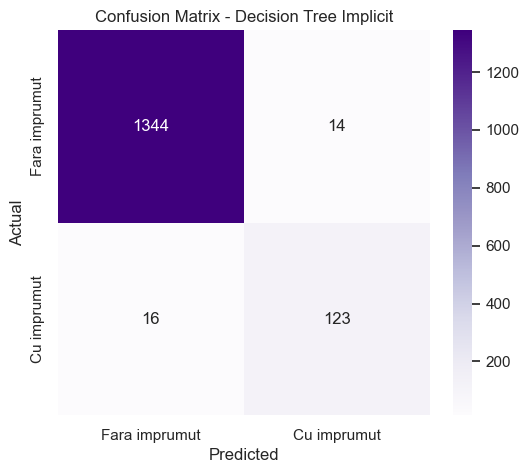

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculăm matricea de confuzie
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Fara imprumut','Cu imprumut'], yticklabels=['Fara imprumut','Cu imprumut'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Implicit')
plt.show()

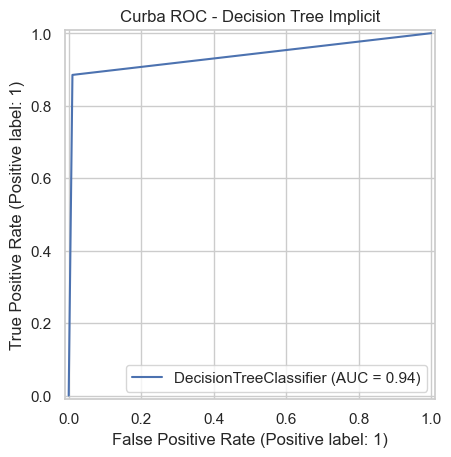

In [100]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    dt_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Decision Tree Implicit")
plt.show()

In [101]:
from sklearn.model_selection import cross_val_score

# Cross-validation 5-fold
cv_scores = cross_val_score(dt_default, X_train_scaled_df, y_train, cv=5, scoring='accuracy')

print("Acuratețe CV pe 5 fold-uri:", cv_scores)
print("Medie acuratețe CV:", np.mean(cv_scores))

Acuratețe CV pe 5 fold-uri: [0.98280802 0.9756447  0.97421203 0.98424069 0.97851003]
Medie acuratețe CV: 0.9790830945558738


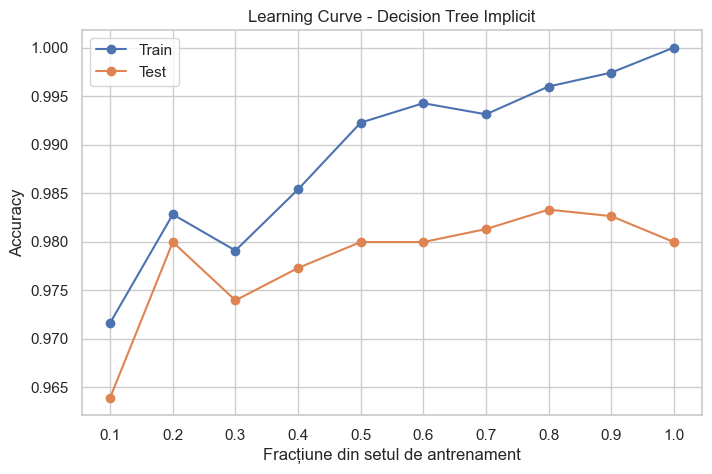

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Listă de dimensiuni pentru subsetul de antrenament
train_sizes_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    
    # Subset din setul de antrenament
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    # Model implicit
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    # Predicții
    y_train_pred = model.predict(X_train_scaled_df)
    y_test_pred = model.predict(X_test_scaled_df)
    
    # Accuracy
    accuracy_train.append(accuracy_score(y_train, y_train_pred))
    accuracy_test.append(accuracy_score(y_test, y_test_pred))

# Plot simplu, ca în exemplul tău cu min_samples_split
plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Decision Tree Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.xticks(train_sizes_list)
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()

- Performanta arborelui de decizie este foarte buna, modelul obtinand o acuratete de 1.00 pe setul de antrenare si 0.98 pe setul de testare. Pentru clasa majoritara (clientii care nu au luat imprumut), modelul are valori foarte ridicate ale metricilor precision, recall si f1‑score, toate fiind 0.99. Pentru clasa minoritara (clientii care au luat imprumut), modelul obtine o precision de 0.90, un recall de 0.88 si un f1‑score de 0.89, ceea ce arata ca reuseste sa identifice corect majoritatea clientilor interesati de imprumut.
- Matricea de confuzie arata cate predictii au fost corecte si cate gresite. Modelul a clasificat corect 1344 clienti fara imprumut si 123 cu imprumut. Au fost 14 cazuri gresite in care modelul a prezis imprumut, dar clientul nu l-a luat, si 16 cazuri in care modelul nu a detectat ca un client a luat imprumutul.
 - Curba ROC arata cat de bine face modelul diferenta intre cei care iau imprumut si cei care nu. Cu o valoare AUC de 0.94, modelul are performanta foarte buna si face predictii precise.

### 5.  Modelul Random Forest

In [125]:
from sklearn.ensemble import RandomForestClassifier

# Model implicit Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_scaled_df, y_train)

# Predicții
y_train_pred = rf_default.predict(X_train_scaled_df)
y_test_pred = rf_default.predict(X_test_scaled_df)

# Acuratețe
print("=== Random Forest Implicit ===")
print(f"Acuratețe Train: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Acuratețe Test: {accuracy_score(y_test, y_test_pred):.3f}")

rf_train  = accuracy_score(y_train, y_train_pred)
rf_test =  accuracy_score(y_test, y_test_pred)

# Classification Report
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))



=== Random Forest Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.988

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1358
           1       0.99      0.88      0.93       139

    accuracy                           0.99      1497
   macro avg       0.99      0.94      0.96      1497
weighted avg       0.99      0.99      0.99      1497



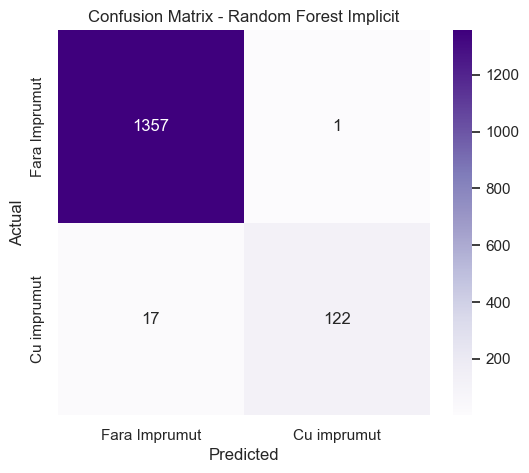

In [104]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Fara Imprumut','Cu imprumut'], yticklabels=['Fara Imprumut','Cu imprumut'])
plt.title('Confusion Matrix - Random Forest Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

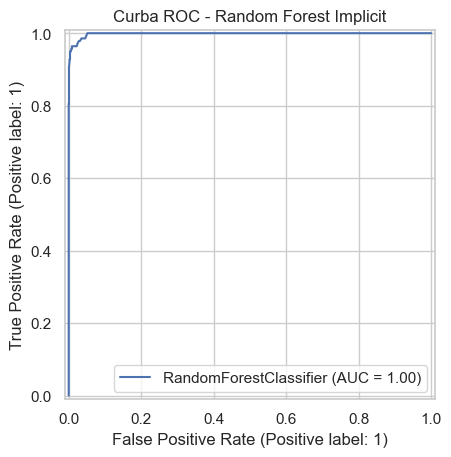

In [105]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    rf_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Random Forest Implicit")
plt.show()

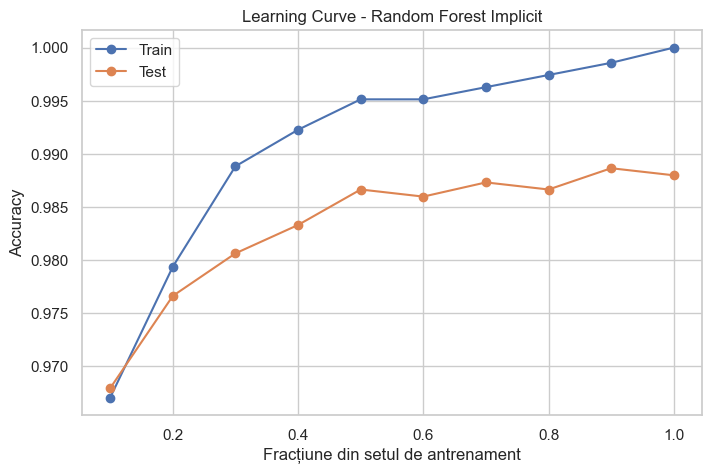

In [106]:
# Learning Curve simplu
train_sizes_list = np.linspace(0.1, 1.0, 10)
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Random Forest Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()


- Random Forest are o performanta usor mai buna decat arborele de decizie. Modelul obtine o acuratete de 0.99 pe setul de testare, fata de 0.98 la arborele de decizie, si reuseste sa clasifice mai bine clasa minoritara (clientii care au luat imprumut). Precision pentru clasa 1 creste la 0.99, iar f1‑score ajunge la 0.93. In plus, Random Forest reduce riscul de overfitting datorita combinarii mai multor arbori, oferind o generalizare mai buna decat un singur arbore de decizie.
- Matricea de confuzie arată cât de bine a prezis modelul Random Forest. Acesta a clasificat corect 1357 de clienți care nu au luat împrumutul și 122 care l-au luat. Au fost doar 1 caz greșit în care modelul a prezis că un client va lua împrumutul, dar nu l-a luat (False Positive), și 17 cazuri în care nu a detectat corect un client care a luat împrumutul (False Negative).
- Curba ROC arată cât de bine face modelul diferența între clienții care iau și cei care nu iau împrumut. Cu o valoare AUC de 1.00, modelul are performanță perfectă, ceea ce înseamnă că reușește să distingă foarte bine între cele două clase.

### 6.  Modelul Boosting (Gradient Boosting / AdaBoost)

<h2 style="color:#875DAF;"> AdaBoost </h2>


In [127]:
from sklearn.ensemble import AdaBoostClassifier

ada_default = AdaBoostClassifier(random_state=42, algorithm='SAMME')
ada_default.fit(X_train_scaled_df, y_train)

# Predicții
y_train_pred = ada_default.predict(X_train_scaled_df)
y_test_pred = ada_default.predict(X_test_scaled_df)

ada_train  = accuracy_score(y_train, y_train_pred)
ada_test =   accuracy_score(y_test, y_test_pred)

# Evaluare
print("=== AdaBoost Implicit ===")
print(f"Accuracy Train: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Accuracy Test: {accuracy_score(y_test, y_test_pred):.3f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

=== AdaBoost Implicit ===
Accuracy Train: 0.963
Accuracy Test: 0.969

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1358
           1       0.87      0.78      0.82       139

    accuracy                           0.97      1497
   macro avg       0.92      0.88      0.90      1497
weighted avg       0.97      0.97      0.97      1497



C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


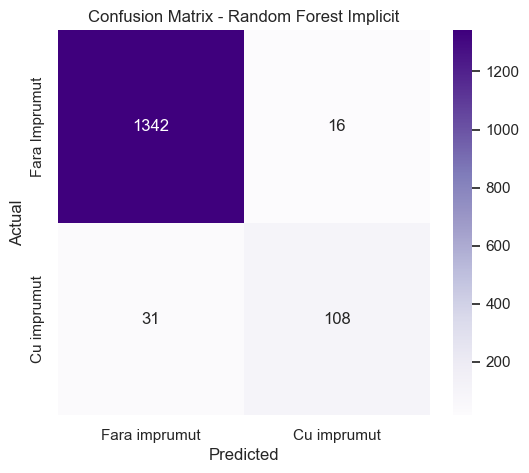

In [128]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Fara imprumut','Cu imprumut'], yticklabels=['Fara Imprumut','Cu imprumut'])
plt.title('Confusion Matrix - Random Forest Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

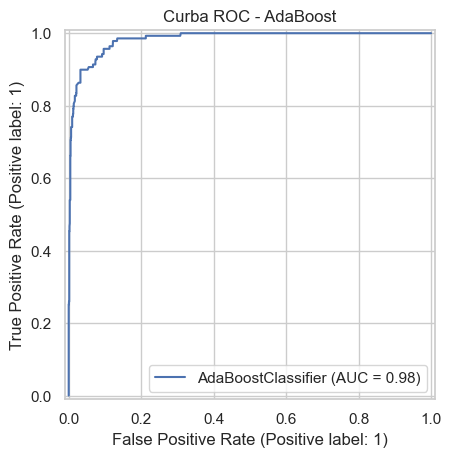

In [129]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    ada_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - AdaBoost")
plt.show()


C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\bursu\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is

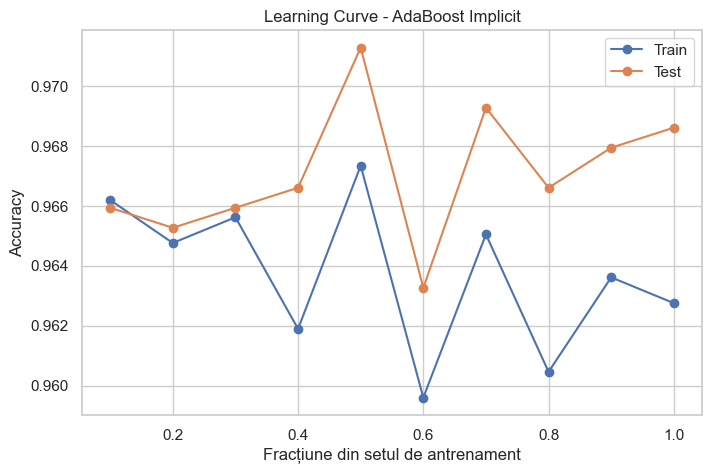

In [130]:
# Learning curve simplu
train_sizes_list = np.linspace(0.1, 1.0, 10)
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - AdaBoost Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()

- Desi Random Forest are o acuratete mai mare pe setul de testare, modelul AdaBoost prezinta un decalaj mai mic intre acuratetea de antrenare (0.963) si cea de testare (0.969). Acest lucru sugereaza ca AdaBoost generalizeaza mai bine si este mai stabil, cu un risc mai mic de overfitting. Acest comportament se observa si in curba de invatare, unde liniile pentru train si test sunt mai apropiate, indicand o performanta echilibrata pe diferite dimensiuni ale setului de antrenament.
- Matricea de confuzie arată câți clienți au fost clasificați corect și câți greșit. Modelul AdaBoost a prezis corect majoritatea cazurilor, dar a avut câteva erori la clienții care au luat împrumutul.
- Curba ROC arată cât de bine separă modelul cele două clase. Cu un AUC de 0.98, AdaBoost are o performanță foarte bună și distinge bine între clienții cu și fără împrumut.


### 7.  Compararea modelelor și concluzii 

In [132]:
models = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'AdaBoost'
    ],
    'Training Accuracy': [
        acc_train,
        rf_train,
        ada_train
  
    ],
    'Model Accurracy Score': [
        acc_test,
        rf_test,
        ada_test
    ]
})

models



,Model,Training Accuracy,Model Accurracy Score
0,Decision Tree,1.000000,0.979960
1,Random Forest,1.000000,0.987976
2,AdaBoost,0.962751,0.968604


Adaboost poate fi considerat mai bun deoarece are o diferenta mai mica intre acuratetea de antrenare si cea de testare, ceea ce arata o generalizare mai buna. In plus, acuratetea pe test este chiar usor mai mare decat pe train, semn ca modelul este stabil si nu sufera de overfitting.